In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
import os
os.chdir(r'C:\Bhavika\02 VIT Chennai\Project\AI_Travel_Analyst')

In [ ]:
df = pd.read_csv('flight_pricing_dataset.csv')
df.head()

,Flight_ID,Airline,Source,Destination,Departure_Date,Departure_Time,Arrival_Time,Duration,Total_Stops,Distance_km,Travel_Class,Days_Before_Departure,Season,Weekday,Aircraft_Type,Booking_Channel,Passenger_Count,Price
0,FL133547,Indigo,Hyderabad,Ahmedabad,2025-08-02,8:10 PM,21:50,1.67,0,910.5,Economy,43,Monsoon,Saturday,Boeing 737,Mobile App,5,5181.56
1,FL133458,AirAsia India,Pune,Mumbai,2025-06-05,12:10,12:55,0h 45m,non-stop,150,Economy,45,Monsoon,Thursday,ATR 72,Website,3,2000
2,FL173851,Qatar Airways,Sydney,PNQ,2025-02-11,5:05 PM,7:53 AM,14.80,1 stop,10168.1,Economy,3,NaN,Tuesday,Boeing 777,Mobile App,3,174762.69
3,FL101953,AirAsia India,Bangalore Airport,BOM,2025-04-19,07:05,10:16 AM,3h 11m,1,868.3,Economy,33,Summer,Saturday,Airbus A320,Mobile App,1,2846.09
4,FL162887,British Airways,Sydney,Goa,2026-07-05,10:40 PM,12:36,13.93,non-stop,10478.0,Economy,6,Monsoon,Sunday,Airbus A320,Website,2,145331.64


In [ ]:
df.columns.tolist()

['Flight_ID',
 'Airline',
 'Source',
 'Destination',
 'Departure_Date',
 'Departure_Time',
 'Arrival_Time',
 'Duration',
 'Total_Stops',
 'Distance_km',
 'Travel_Class',
 'Days_Before_Departure',
 'Season',
 'Weekday',
 'Aircraft_Type',
 'Booking_Channel',
 'Passenger_Count',
 'Price']

In [ ]:
df.shape


(100000, 18)

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column                 Non-Null Count   Dtype 
---  ------                 --------------   ----- 
 0   Flight_ID              100000 non-null  object
 1   Airline                95120 non-null   object
 2   Source                 95085 non-null   object
 3   Destination            95119 non-null   object
 4   Departure_Date         95073 non-null   object
 5   Departure_Time         95132 non-null   object
 6   Arrival_Time           95211 non-null   object
 7   Duration               94958 non-null   object
 8   Total_Stops            95095 non-null   object
 9   Distance_km            95077 non-null   object
 10  Travel_Class           95137 non-null   object
 11  Days_Before_Departure  95216 non-null   object
 12  Season                 95224 non-null   object
 13  Weekday                95280 non-null   object
 14  Aircraft_Type          95148 non-null   object
 15  B

In [ ]:
df.describe()


,Flight_ID,Airline,Source,Destination,Departure_Date,Departure_Time,Arrival_Time,Duration,Total_Stops,Distance_km,Travel_Class,Days_Before_Departure,Season,Weekday,Aircraft_Type,Booking_Channel,Passenger_Count,Price
count,100000,95120,95085,95119,95073,95132,95211,94958,95095,95077,95137,95216,95224,95280,95148,95038,95174,94947
unique,98039,39,54,54,730,576,2880,5111,6,59484,4,341,4,7,8,5,12,78725
top,FL195438,Singapore Airlines,Chennai,Goa,2025-04-05,09:50,06:24,1h 10m,1,150,Economy,0,Monsoon,Sunday,Airbus A320,Website,1,200000
freq,3,7864,3519,3503,168,242,64,377,26710,590,64867,3554,31808,13809,20450,30696,39079,8989


In [ ]:
print(df['Price'].unique()[:20])
print(df['Distance_km'].unique()[:20])
print(df['Duration'].unique()[:20])
print(df['Total_Stops'].unique()[:20])


['5181.56' '2000' '174762.69' '2846.09' '145331.64' '190059.64' '6458.88'
 '28599.41' '147645.15' nan '24660.74' '36225.75' '15000' '200000'
 '20785.21' '32822.58' '193690.74' '43430.61' '9024.38' 'Rs. 151,632.89']
['910.5' '150' '10168.1' '868.3' '10478.0' nan '748.9' '2574.9' '12133.2'
 '2215.6' '1904.9' '3179.9' '376.4' '15583.5' '1189.7' '1624.9' '15941.1'
 '14240.1' '3523.9' '1151.0']
['1.67' '0h 45m' '14.80' '3h 11m' '13.93' '16h 47m' '1h 28m' '5h 27m'
 '17h 04m' '3h 20m' '177 min' nan '0h 59m' '2h 02m' '155 min' '22h 40m'
 '18h 45m' '6h 04m' '1.98' '2h 38m']
['0' 'non-stop' '1 stop' '1' nan '2 stops' '2']


In [ ]:
df['Price'] = df['Price'].astype(str).str.replace('Rs.', '', regex=False)
df['Price'] = df['Price'].str.replace(',', '', regex=False)
df['Price'] = df['Price'].str.strip()
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

# Clean Distance_km: just convert to number
df['Distance_km'] = pd.to_numeric(df['Distance_km'], errors='coerce')

# Clean Total_Stops: map words to numbers
df['Total_Stops'] = df['Total_Stops'].astype(str).str.replace('non-stop', '0', regex=False)
df['Total_Stops'] = df['Total_Stops'].str.extract('(\d+)')  # pulls out just the digit
df['Total_Stops'] = pd.to_numeric(df['Total_Stops'], errors='coerce')

# Check the results
print(df[['Price', 'Distance_km', 'Total_Stops']].dtypes)
df[['Price', 'Distance_km', 'Total_Stops']].head(10)

Price          float64
Distance_km    float64
Total_Stops    float64
dtype: object


,Price,Distance_km,Total_Stops
0,5181.56,910.5,0.0
1,2000.00,150.0,0.0
2,174762.69,10168.1,1.0
3,2846.09,868.3,1.0
4,145331.64,10478.0,0.0
5,190059.64,NaN,1.0
6,6458.88,748.9,0.0
7,28599.41,2574.9,NaN
8,147645.15,12133.2,1.0
9,NaN,2215.6,0.0


In [ ]:
import re
import numpy as np

def parse_duration(val):
    if pd.isna(val):
        return np.nan
    val = str(val).strip()
    
    match = re.match(r'^(\d+)h\s*(\d+)m$', val)
    if match:
        hours, minutes = match.groups()
        return int(hours) * 60 + int(minutes)
    
    match = re.match(r'^([\d.]+)\s*min$', val)
    if match:
        return float(match.group(1))
    try:
        return float(val) * 60
    except ValueError:
        return np.nan

df['Duration_min'] = df['Duration'].apply(parse_duration)

print(df['Duration_min'].dtype)
df[['Duration', 'Duration_min']].head(15)

float64


,Duration,Duration_min
0,1.67,100.2
1,0h 45m,45.0
2,14.80,888.0
3,3h 11m,191.0
4,13.93,835.8
5,16h 47m,1007.0
6,1h 28m,88.0
7,5h 27m,327.0
8,17h 04m,1024.0
9,3h 20m,200.0


In [ ]:
df.isnull().sum()


Flight_ID                   0
Airline                  4880
Source                   4915
Destination              4881
Departure_Date           4927
Departure_Time           4868
Arrival_Time             4789
Duration                 5042
Total_Stops              4905
Distance_km              7758
Travel_Class             4863
Days_Before_Departure    4784
Season                   4776
Weekday                  4720
Aircraft_Type            4852
Booking_Channel          4962
Passenger_Count          4826
Price                    5053
Duration_min             5042
dtype: int64

In [ ]:
df = df.dropna(subset=['Price'])

# 2. Fill missing numeric columns with median
numeric_cols = ['Distance_km', 'Duration_min', 'Total_Stops', 'Days_Before_Departure', 'Passenger_Count']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')  # ensure numeric first
    df[col] = df[col].fillna(df[col].median())

# 3. Fill missing categorical columns with "Unknown"
categorical_cols = ['Airline', 'Source', 'Destination', 'Travel_Class', 'Season', 'Weekday', 'Aircraft_Type', 'Booking_Channel']
for col in categorical_cols:
    df[col] = df[col].fillna('Unknown')

# Check progress
df.isnull().sum()

Flight_ID                   0
Airline                     0
Source                      0
Destination                 0
Departure_Date           4678
Departure_Time           4632
Arrival_Time             4556
Duration                 4777
Total_Stops                 0
Distance_km                 0
Travel_Class                0
Days_Before_Departure       0
Season                      0
Weekday                     0
Aircraft_Type               0
Booking_Channel             0
Passenger_Count             0
Price                       0
Duration_min                0
dtype: int64

In [ ]:
df['Departure_Date'] = pd.to_datetime(df['Departure_Date'], errors='coerce')

# Peek at what the time columns actually contain
print(df['Departure_Time'].dropna().unique()[:10])
print(df['Arrival_Time'].dropna().unique()[:10])

df.isnull().sum()

['8:10 PM' '12:10' '5:05 PM' '07:05' '10:40 PM' '4:15 AM' '1:35 AM'
 '9:55 AM' '5:45 AM' '13:30']
['21:50' '12:55' '7:53 AM' '10:16 AM' '12:36' '21:02' '3:02 AM' '3:21 PM'
 '22:49' '16:26']


Flight_ID                   0
Airline                     0
Source                      0
Destination                 0
Departure_Date           4678
Departure_Time           4632
Arrival_Time             4556
Duration                 4777
Total_Stops                 0
Distance_km                 0
Travel_Class                0
Days_Before_Departure       0
Season                      0
Weekday                     0
Aircraft_Type               0
Booking_Channel             0
Passenger_Count             0
Price                       0
Duration_min                0
dtype: int64

In [ ]:
df['Departure_Time'] = pd.to_datetime(df['Departure_Time'], errors='coerce').dt.time
df['Arrival_Time'] = pd.to_datetime(df['Arrival_Time'], errors='coerce').dt.time

# Check how many failed to convert
print(df['Departure_Time'].isnull().sum())
print(df['Arrival_Time'].isnull().sum())

C:\Users\Bhavika\AppData\Local\Temp\ipykernel_29980\533206256.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Departure_Time'] = pd.to_datetime(df['Departure_Time'], errors='coerce').dt.time
C:\Users\Bhavika\AppData\Local\Temp\ipykernel_29980\533206256.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Arrival_Time'] = pd.to_datetime(df['Arrival_Time'], errors='coerce').dt.time


4632
4556


In [ ]:
print(df.duplicated().sum())


1864


In [ ]:
df = df.drop_duplicates()

# Confirm
print(df.duplicated().sum())
print(df.shape)

0
(93083, 19)


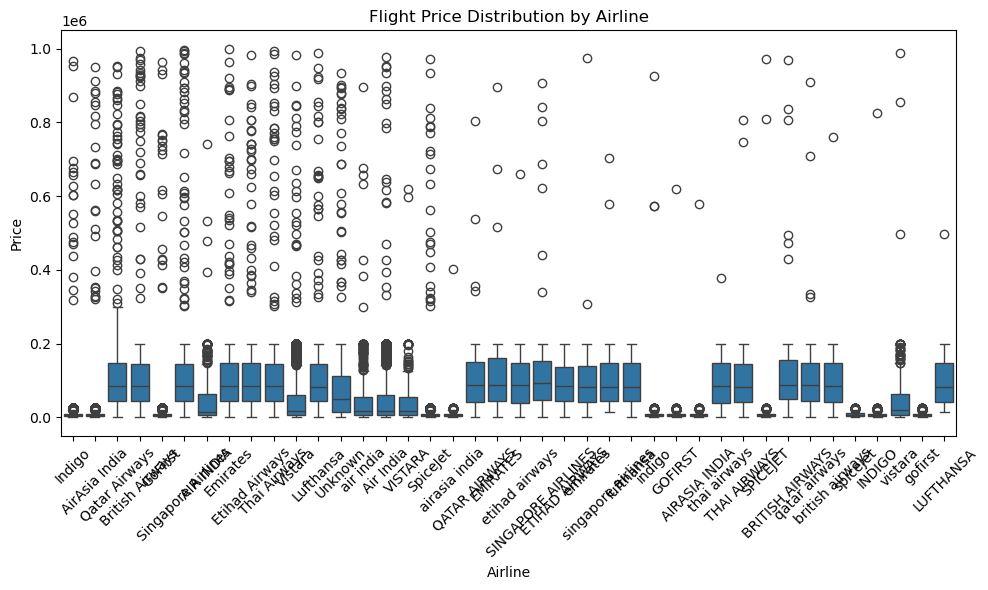

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Airline', y='Price')
plt.xticks(rotation=45)
plt.title('Flight Price Distribution by Airline')
plt.xlabel('Airline')
plt.ylabel('Price')
plt.tight_layout()
plt.show()

In [ ]:
df['Airline'] = df['Airline'].str.strip().str.title()

# Check how many unique airlines remain
print(df['Airline'].nunique())
print(df['Airline'].unique())

14
['Indigo' 'Airasia India' 'Qatar Airways' 'British Airways' 'Gofirst'
 'Singapore Airlines' 'Air India' 'Emirates' 'Etihad Airways'
 'Thai Airways' 'Vistara' 'Lufthansa' 'Unknown' 'Spicejet']


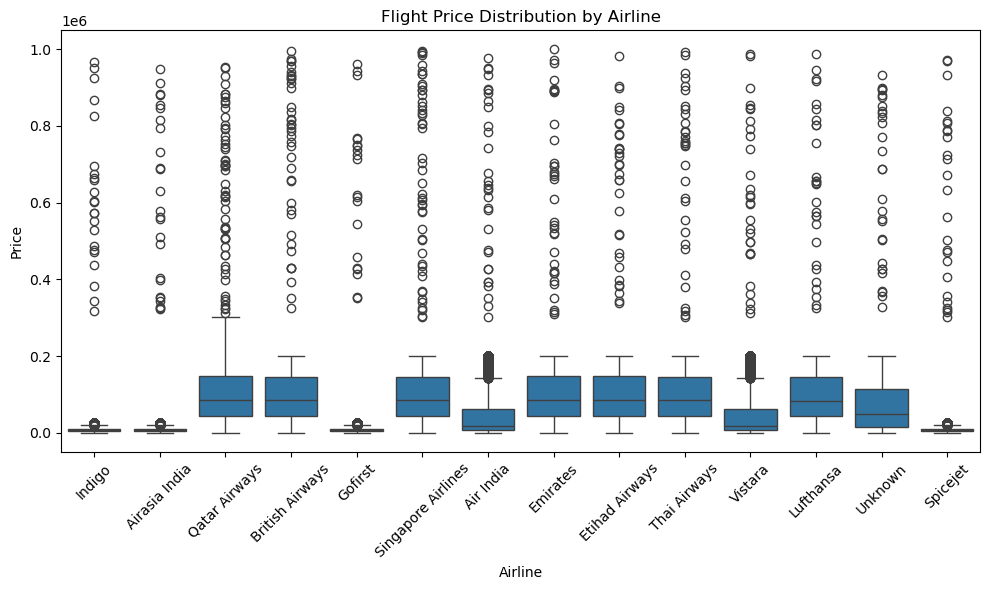

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Airline', y='Price')
plt.xticks(rotation=45)
plt.title('Flight Price Distribution by Airline')
plt.xlabel('Airline')
plt.ylabel('Price')
plt.tight_layout()
plt.show()

In [ ]:
for col in ['Source', 'Destination', 'Travel_Class', 'Season', 'Weekday', 'Aircraft_Type', 'Booking_Channel']:
    print(col, ':', df[col].nunique(), 'unique values')
    print(df[col].unique())
    print()

Source : 55 unique values
['Hyderabad' 'Pune' 'Sydney' 'Bangalore Airport' 'New York' 'HYD' 'DXB'
 'Unknown' 'Doha' 'Singapore Airport' 'Kolkata' 'Singapore' 'SIN' 'BOM'
 'Delhi Airport' 'Doha Airport' 'Jaipur' 'New York Airport' 'JAI' 'Mumbai'
 'DOH' 'Bangkok' 'Bangalore' 'Chennai Airport' 'Delhi' 'BLR' 'Dubai'
 'Goa Airport' 'AMD' 'Chennai' 'BKK' 'JFK' 'Ahmedabad' 'Bangkok Airport'
 'Mumbai Airport' 'London' 'Goa' 'PNQ' 'SYD' 'London Airport' 'Frankfurt'
 'Ahmedabad Airport' 'GOI' 'Jaipur Airport' 'Pune Airport' 'DEL'
 'Dubai Airport' 'FRA' 'LHR' 'Frankfurt Airport' 'CCU' 'Kolkata Airport'
 'Sydney Airport' 'Hyderabad Airport' 'MAA']

Destination : 55 unique values
['Ahmedabad' 'Mumbai' 'PNQ' 'BOM' 'Goa' 'Doha' 'Bangalore' 'Dubai'
 'Jaipur Airport' 'BKK' 'Dubai Airport' 'New York Airport' 'Kolkata'
 'New York' 'Hyderabad' 'Delhi' 'FRA' 'Unknown' 'SYD' 'Hyderabad Airport'
 'MAA' 'Pune Airport' 'Bangkok' 'Singapore' 'Jaipur' 'Sydney'
 'Chennai Airport' 'London' 'Singapore Airport' 'DOH

In [ ]:
print(sorted(df['Source'].unique()))
print(sorted(df['Destination'].unique()))

['AMD', 'Ahmedabad', 'Ahmedabad Airport', 'BKK', 'BLR', 'BOM', 'Bangalore', 'Bangalore Airport', 'Bangkok', 'Bangkok Airport', 'CCU', 'Chennai', 'Chennai Airport', 'DEL', 'DOH', 'DXB', 'Delhi', 'Delhi Airport', 'Doha', 'Doha Airport', 'Dubai', 'Dubai Airport', 'FRA', 'Frankfurt', 'Frankfurt Airport', 'GOI', 'Goa', 'Goa Airport', 'HYD', 'Hyderabad', 'Hyderabad Airport', 'JAI', 'JFK', 'Jaipur', 'Jaipur Airport', 'Kolkata', 'Kolkata Airport', 'LHR', 'London', 'London Airport', 'MAA', 'Mumbai', 'Mumbai Airport', 'New York', 'New York Airport', 'PNQ', 'Pune', 'Pune Airport', 'SIN', 'SYD', 'Singapore', 'Singapore Airport', 'Sydney', 'Sydney Airport', 'Unknown']
['AMD', 'Ahmedabad', 'Ahmedabad Airport', 'BKK', 'BLR', 'BOM', 'Bangalore', 'Bangalore Airport', 'Bangkok', 'Bangkok Airport', 'CCU', 'Chennai', 'Chennai Airport', 'DEL', 'DOH', 'DXB', 'Delhi', 'Delhi Airport', 'Doha', 'Doha Airport', 'Dubai', 'Dubai Airport', 'FRA', 'Frankfurt', 'Frankfurt Airport', 'GOI', 'Goa', 'Goa Airport', 'HYD'

In [ ]:
city_map = {
    'AMD': 'Ahmedabad', 'Ahmedabad Airport': 'Ahmedabad',
    'BLR': 'Bangalore', 'Bangalore Airport': 'Bangalore',
    'BKK': 'Bangkok', 'Bangkok Airport': 'Bangkok',
    'BOM': 'Mumbai', 'Mumbai Airport': 'Mumbai',
    'CCU': 'Kolkata', 'Kolkata Airport': 'Kolkata',
    'DEL': 'Delhi', 'Delhi Airport': 'Delhi',
    'DOH': 'Doha', 'Doha Airport': 'Doha',
    'DXB': 'Dubai', 'Dubai Airport': 'Dubai',
    'FRA': 'Frankfurt', 'Frankfurt Airport': 'Frankfurt',
    'GOI': 'Goa', 'Goa Airport': 'Goa',
    'HYD': 'Hyderabad', 'Hyderabad Airport': 'Hyderabad',
    'JAI': 'Jaipur', 'Jaipur Airport': 'Jaipur',
    'JFK': 'New York', 'New York Airport': 'New York',
    'LHR': 'London', 'London Airport': 'London',
    'MAA': 'Chennai', 'Chennai Airport': 'Chennai',
    'PNQ': 'Pune', 'Pune Airport': 'Pune',
    'SIN': 'Singapore', 'Singapore Airport': 'Singapore',
    'SYD': 'Sydney', 'Sydney Airport': 'Sydney',
}

df['Source'] = df['Source'].replace(city_map)
df['Destination'] = df['Destination'].replace(city_map)

print(df['Source'].nunique())
print(sorted(df['Source'].unique()))

19
['Ahmedabad', 'Bangalore', 'Bangkok', 'Chennai', 'Delhi', 'Doha', 'Dubai', 'Frankfurt', 'Goa', 'Hyderabad', 'Jaipur', 'Kolkata', 'London', 'Mumbai', 'New York', 'Pune', 'Singapore', 'Sydney', 'Unknown']


In [ ]:
print(df['Source'].nunique())
print(sorted(df['Source'].unique()))

19
['Ahmedabad', 'Bangalore', 'Bangkok', 'Chennai', 'Delhi', 'Doha', 'Dubai', 'Frankfurt', 'Goa', 'Hyderabad', 'Jaipur', 'Kolkata', 'London', 'Mumbai', 'New York', 'Pune', 'Singapore', 'Sydney', 'Unknown']


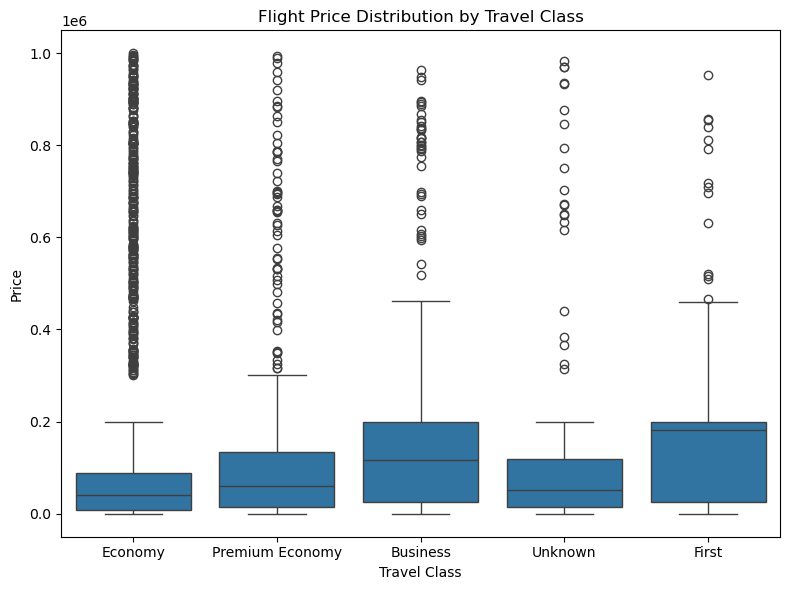

In [ ]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='Travel_Class', y='Price')
plt.title('Flight Price Distribution by Travel Class')
plt.xlabel('Travel Class')
plt.ylabel('Price')
plt.tight_layout()
plt.savefig('chart2_price_by_class.png', dpi=150, bbox_inches='tight')
plt.show()

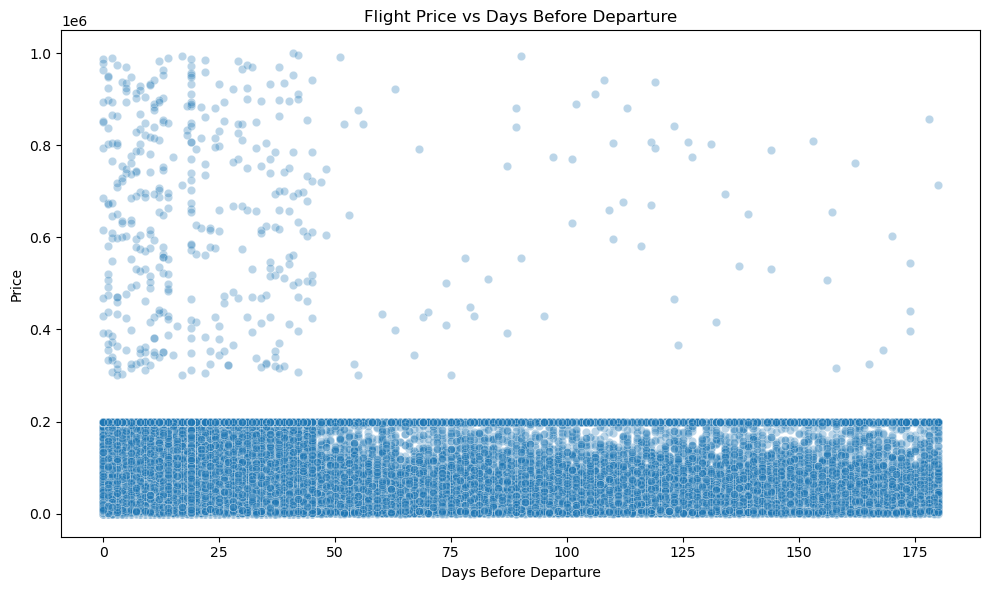

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Days_Before_Departure', y='Price', alpha=0.3)
plt.title('Flight Price vs Days Before Departure')
plt.xlabel('Days Before Departure')
plt.ylabel('Price')
plt.tight_layout()
plt.savefig('chart3_price_vs_days_before.png', dpi=150, bbox_inches='tight')
plt.show()

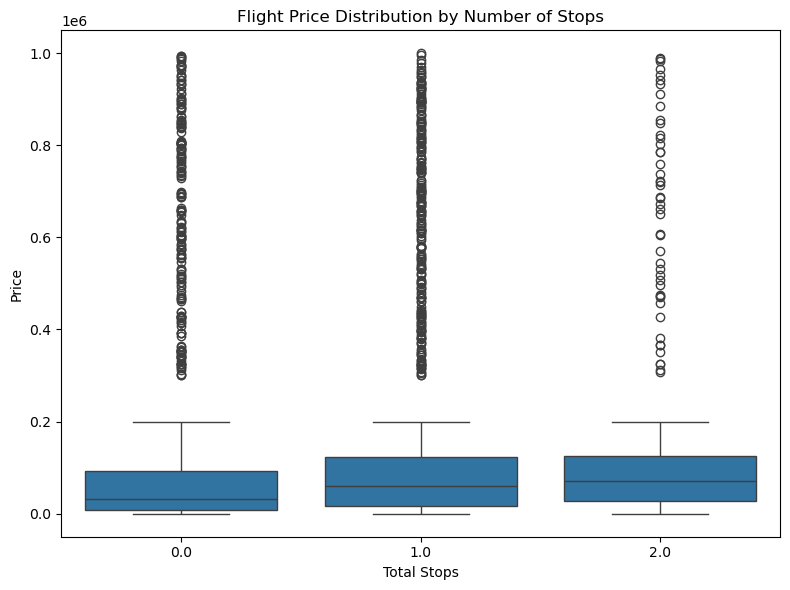

In [ ]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='Total_Stops', y='Price')
plt.title('Flight Price Distribution by Number of Stops')
plt.xlabel('Total Stops')
plt.ylabel('Price')
plt.tight_layout()
plt.savefig('chart4_price_by_stops.png', dpi=150, bbox_inches='tight')
plt.show()

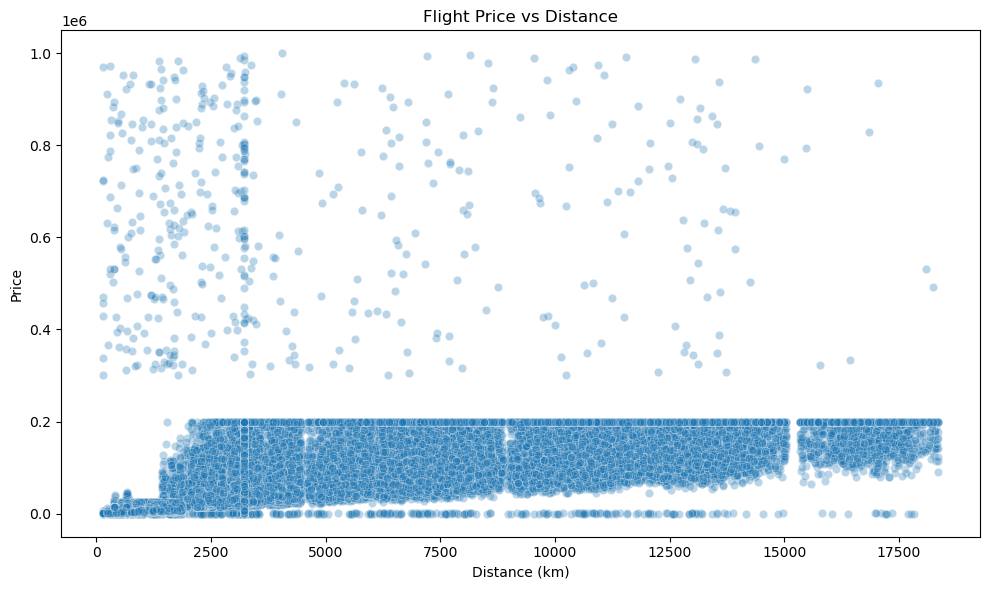

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Distance_km', y='Price', alpha=0.3)
plt.title('Flight Price vs Distance')
plt.xlabel('Distance (km)')
plt.ylabel('Price')
plt.tight_layout()
plt.savefig('chart5_price_vs_distance.png', dpi=150, bbox_inches='tight')
plt.show()

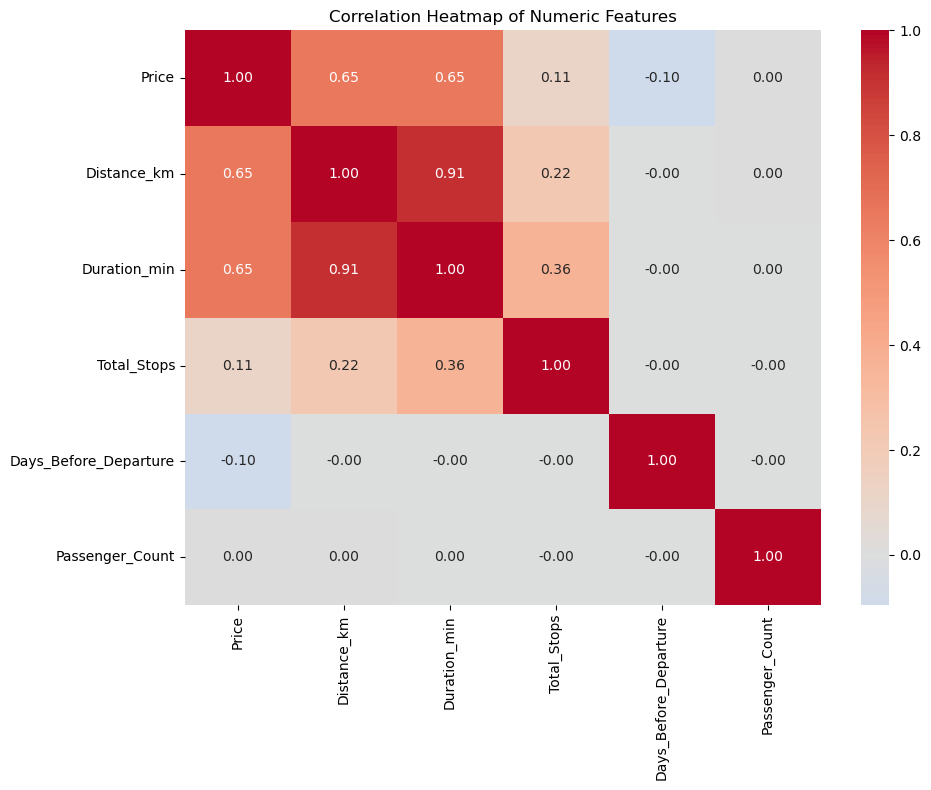

In [ ]:
plt.figure(figsize=(10,8))
numeric_features = ['Price', 'Distance_km', 'Duration_min', 'Total_Stops', 'Days_Before_Departure', 'Passenger_Count']
corr_matrix = df[numeric_features].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', center=0)
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.savefig('chart6_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

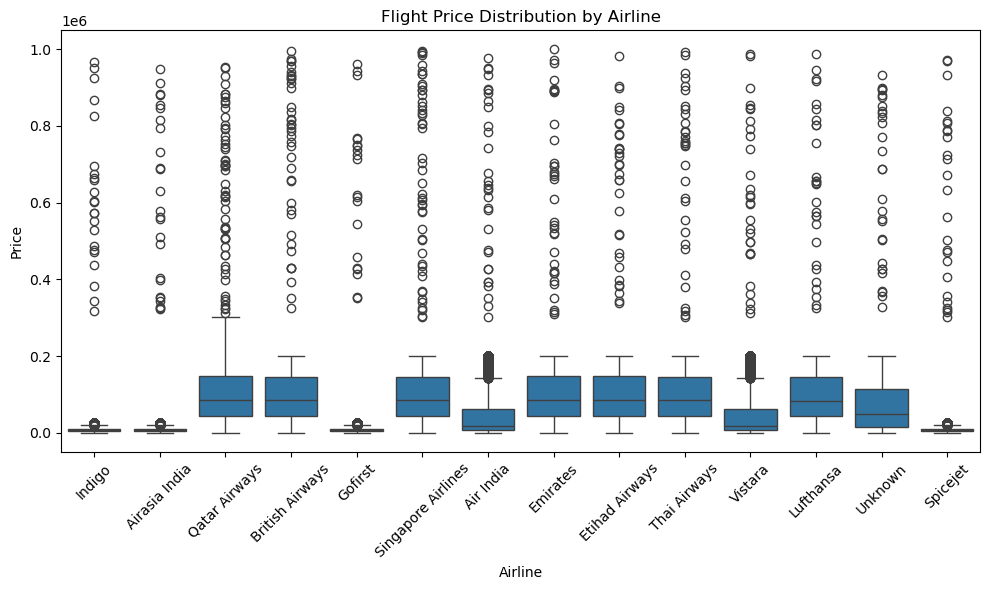

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Airline', y='Price')
plt.xticks(rotation=45)
plt.title('Flight Price Distribution by Airline')
plt.xlabel('Airline')
plt.ylabel('Price')
plt.tight_layout()
plt.savefig('chart1_price_by_airline.png', dpi=150, bbox_inches='tight')
plt.show()

## Insights & Recommendations

### What actually affects flight price

After cleaning and exploring the data, a few things stood out clearly.

**Distance and flight duration matter the most.** Both had a correlation of about 0.65 with price, which was the strongest relationship I found. Basically, the farther and longer the flight, the more it costs — flights over 15,000 km were consistently in the higher price range. Distance and duration are obviously tied to each other too (0.91 correlation), which makes sense since a longer route just takes more time.

**Travel class makes a big difference.** Economy is cheapest, then Premium Economy, then Business, then First — and the price gap between them isn't small. This was one of the clearest patterns in the whole dataset.

**Airline matters more than I expected.** Budget airlines like Indigo, SpiceJet, GoFirst, and AirAsia India stayed in a low, tight price range across the board. Airlines like Qatar Airways, Emirates, Lufthansa, and Singapore Airlines were priced higher on average, but also had way more variation — probably because they cover more route types and fare options.

**Number of stops barely matters.** I expected non-stop flights to be pricier (convenience), but the data showed only a small increase in price as stops went up (0.11 correlation) — not a strong effect either way.

**Booking early doesn't save much on average**, but it does seem to reduce risk. Flights booked within the last 50 days before departure had a much wider spread of prices, including a lot more expensive outliers. So booking late doesn't guarantee a high price, but it makes it more likely.

**Number of passengers had basically no effect on price** (correlation close to 0), which was a bit surprising but makes sense since this dataset looks like it's per-ticket pricing rather than per-booking.

### A few practical takeaways

- If you want to save money, focus on which airline and class you pick — that matters way more than timing your booking perfectly.
- Booking more than ~50 days out is still a good idea, mainly to avoid the risk of last-minute price spikes, even if it doesn't guarantee the cheapest fare.
- Don't avoid connecting flights just to save money — the data doesn't really support that non-stop flights cost more.
- For longer trips, expect the price to scale up pretty steadily with distance — it's one of the more predictable factors here.